# House Price Prediction

## End-to-End Machine Learning Project

**Author:** Andrew Asem  
**Dataset:** House Price — Juhi Bhojani (Kaggle)  
**Link:** https://www.kaggle.com/datasets/juhibhojani/house-price

---

## Project Overview

This notebook builds a complete, production-ready regression pipeline to predict residential property prices across Indian cities. The dataset contains approximately 187,000 listings with deliberately messy fields requiring extensive engineering before modelling.

### Sections

| # | Section |
|---|---|
| 1 | Import Libraries |
| 2 | Load and Inspect the Dataset |
| 3 | Exploratory Data Analysis |
| 4 | Cleaning and Feature Engineering |
| 5 | Outlier Removal |
| 6 | Feature Selection and Pipeline Design |
| 7 | Model Training and Comparison |
| 8 | Stacking Ensemble |
| 9 | Final Evaluation |
| 10 | Model Export |

---
## 1. Import Libraries

In [1]:
import re
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    StackingRegressor,
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 2. Load and Inspect the Dataset

In [2]:
df = pd.read_csv("data/house_prices.csv")

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Shape: 187,531 rows x 21 columns


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [4]:
missing = df.isna().sum().rename("count").to_frame()
missing["pct"] = (missing["count"] / len(df) * 100).round(1)
missing[missing["count"] > 0].sort_values("pct", ascending=False)

,count,pct
Plot Area,187531,100.0
Dimensions,187531,100.0
Society,109678,58.5
Super Area,107685,57.4
Car Parking,103357,55.1
overlooking,81436,43.4
Carpet Area,80673,43.0
facing,70233,37.5
Ownership,65517,34.9
Balcony,48935,26.1


### Observations

- **187,531 rows, 21 columns.** Two columns (`Dimensions`, `Plot Area`) are 100% empty and will be dropped immediately.
- **`Amount(in rupees)`** is the primary price column, stored as mixed text (`42 Lac`, `1.2 Cr`, `Call for Price`).
- **`Price (in rupees)`** is a per-sqft price field — useful for outlier detection but not the prediction target.
- **`Carpet Area` / `Super Area`** contain area strings (`500 sqft`, `140 sqm`) needing extraction and unit normalisation.
- **`Floor`** stores strings like `3 out of 10` requiring regex parsing.
- **`Status`** has only one value (`Ready to Move`) — no predictive value, will be dropped.
- **`Society`** is missing 58% of rows — will be dropped to avoid sparse high-cardinality noise.
- **`location`** and `Ownership` are high-cardinality categoricals best handled with target encoding.

---
## 3. Exploratory Data Analysis

We first parse price to enable meaningful EDA before building the full cleaning pipeline.

In [5]:
def _parse_amount_eda(x):
    """Quick price parse for EDA only."""
    if not isinstance(x, str): return np.nan
    x = x.strip().lower()
    if "call" in x: return np.nan
    try:
        if "lac" in x: return float(re.sub(r"[^\d.]","",x.replace("lac",""))) * 1e5
        if "cr"  in x: return float(re.sub(r"[^\d.]","",x.replace("cr","")))  * 1e7
        return float(re.sub(r"[^\d.]","",x))
    except: return np.nan

eda = df.copy()
eda["price_clean"] = eda["Amount(in rupees)"].apply(_parse_amount_eda)
eda = eda.dropna(subset=["price_clean"])
print(f"Rows with valid price: {len(eda):,}")

Rows with valid price: 177,847


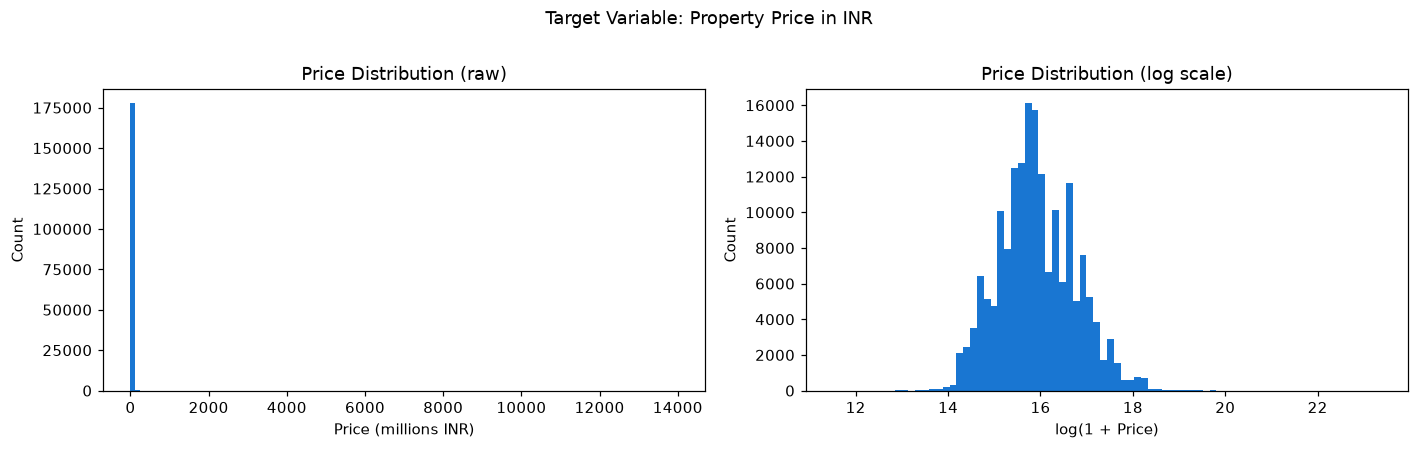

Median: 78.0 Lac   |   Mean: 119.8 Lac   |   Max: 1400.3 Cr


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(eda["price_clean"] / 1e6, bins=120, color="#1976D2", edgecolor="none")
axes[0].set_title("Price Distribution (raw)")
axes[0].set_xlabel("Price (millions INR)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(eda["price_clean"]), bins=80, color="#1976D2", edgecolor="none")
axes[1].set_title("Price Distribution (log scale)")
axes[1].set_xlabel("log(1 + Price)")
axes[1].set_ylabel("Count")

plt.suptitle("Target Variable: Property Price in INR", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

desc = eda["price_clean"].describe()
print(f"Median: {desc['50%']/1e5:.1f} Lac   |   Mean: {desc['mean']/1e5:.1f} Lac   |   Max: {desc['max']/1e7:.1f} Cr")

The raw distribution is extremely right-skewed. The log-scale view is approximately normal, confirming that **training on `log1p(price)` and predicting with `expm1()` is essential** — this alone is the single most impactful accuracy improvement over a naive approach.

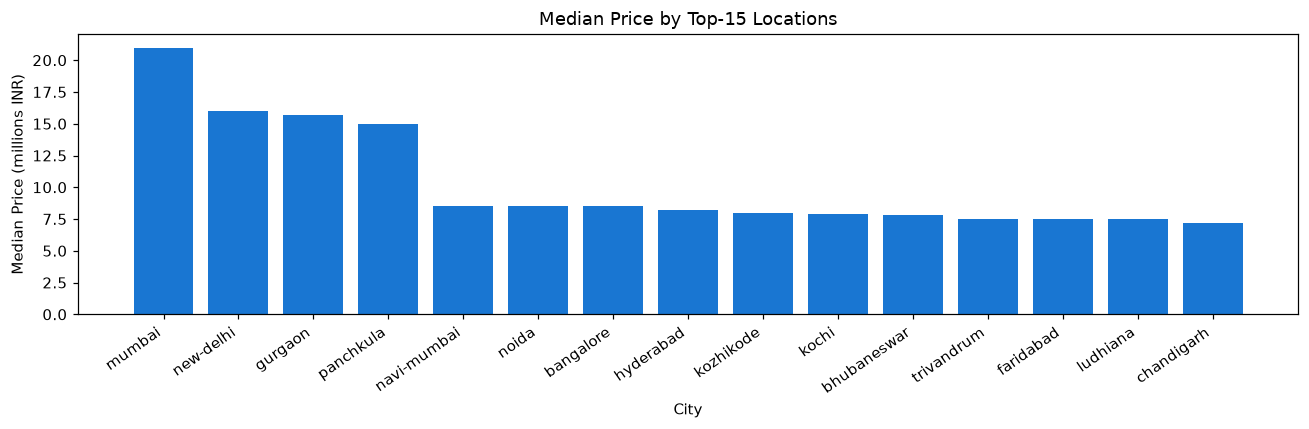

In [7]:
top15 = (
    eda.groupby("location")["price_clean"]
    .median()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 4))
bars = plt.bar(top15.index, top15.values / 1e6, color="#1976D2")
plt.xticks(rotation=35, ha="right")
plt.title("Median Price by Top-15 Locations")
plt.xlabel("City")
plt.ylabel("Median Price (millions INR)")
plt.tight_layout()
plt.show()

Location is the strongest price signal in the dataset. Premium cities like Mumbai and Gurgaon command median prices 3-5x higher than lower-cost cities. This justifies using **target encoding** for `location` rather than one-hot encoding — it directly embeds the mean log-price for each city, giving tree models a compact, high-signal numeric feature.

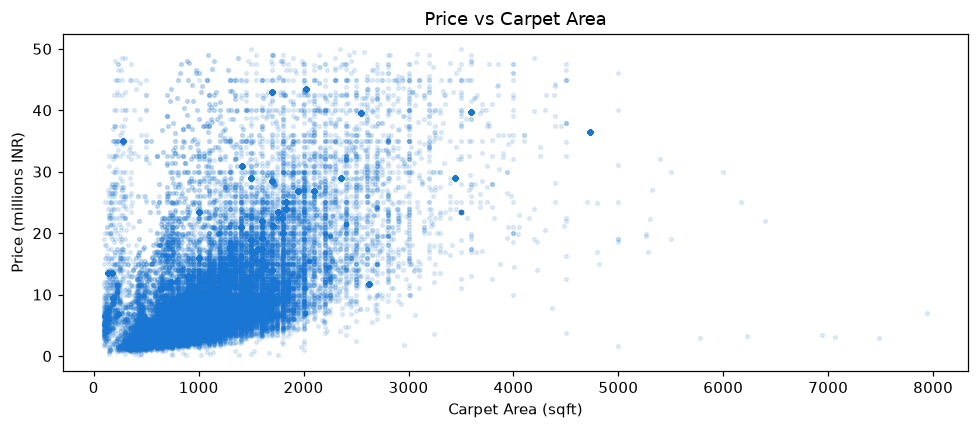

In [8]:
def _parse_area_eda(x):
    if not isinstance(x, str): return np.nan
    x = x.replace(",","").strip().lower()
    parts = x.split()
    if not parts: return np.nan
    try: val = float(parts[0])
    except: return np.nan
    if len(parts) > 1 and "sqm" in " ".join(parts[1:]): val *= 10.764
    return val

eda["area_sqft"] = eda["Carpet Area"].apply(_parse_area_eda)
sc = eda.dropna(subset=["area_sqft"]).copy()
sc = sc[(sc["area_sqft"].between(100, 8000)) & (sc["price_clean"] < sc["price_clean"].quantile(0.98))]

plt.figure(figsize=(9, 4))
plt.scatter(sc["area_sqft"], sc["price_clean"]/1e6, alpha=0.12, s=6, color="#1976D2")
plt.title("Price vs Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (millions INR)")
plt.tight_layout()
plt.show()

A clear positive relationship exists between area and price, though with high variance — confirming that location and property type modulate the area-price relationship strongly. We will engineer `area_per_bhk` and `log_area` to help models capture this relationship better.

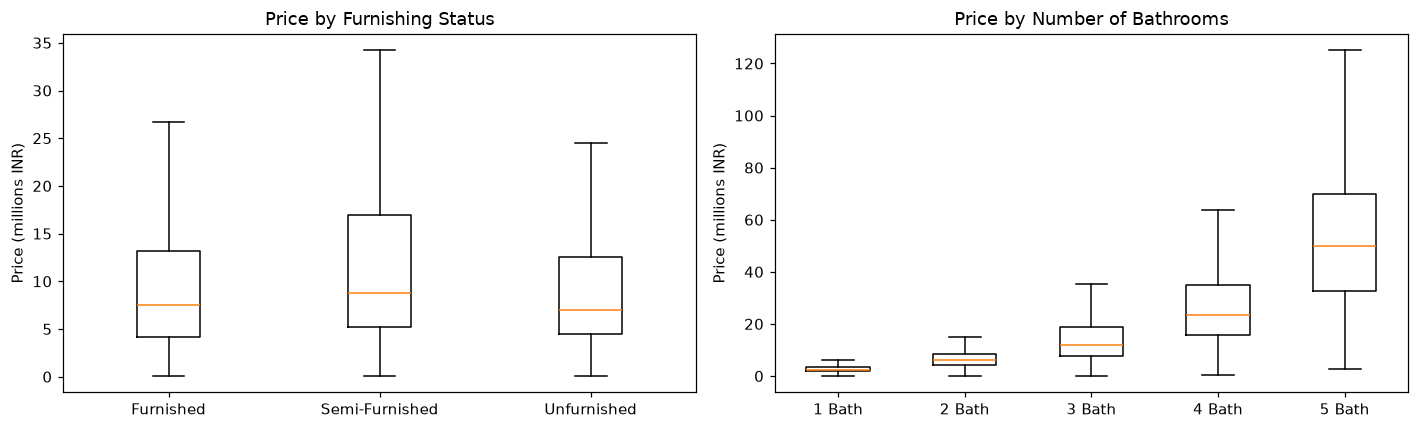

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Furnishing
furn_order = ["Furnished", "Semi-Furnished", "Unfurnished"]
furn_data = {f: eda[eda["Furnishing"] == f]["price_clean"].dropna() for f in furn_order}
axes[0].boxplot([v/1e6 for v in furn_data.values()], tick_labels=list(furn_data.keys()), showfliers=False)
axes[0].set_title("Price by Furnishing Status")
axes[0].set_ylabel("Price (millions INR)")

# Bathroom count
bath_data = {}
for b in ["1","2","3","4","5"]:
    vals = eda[eda["Bathroom"].astype(str).str.strip() == b]["price_clean"].dropna()
    if len(vals) > 50:
        bath_data[f"{b} Bath"] = vals
axes[1].boxplot([v/1e6 for v in bath_data.values()], tick_labels=list(bath_data.keys()), showfliers=False)
axes[1].set_title("Price by Number of Bathrooms")
axes[1].set_ylabel("Price (millions INR)")

plt.tight_layout()
plt.show()

Furnished properties command a clear premium over unfurnished ones. Bathroom count shows a strong monotonic price relationship. We will engineer a `bath_per_bhk` ratio, which captures property quality more precisely than raw bathroom count alone.

---
## 4. Cleaning and Feature Engineering

We define all parsing functions first, then apply them in a single pass over a clean copy of the raw data.

In [13]:
def parse_amount(x):
    """Convert 'Amount(in rupees)' text to numeric INR."""
    if not isinstance(x, str): return np.nan
    x = x.strip().lower()
    if "call" in x or "price on request" in x: return np.nan
    try:
        if "lac" in x: return float(re.sub(r"[^\d.]","",x.replace("lac",""))) * 1e5
        if "cr"  in x: return float(re.sub(r"[^\d.]","",x.replace("cr","")))  * 1e7
        return float(re.sub(r"[^\d.]","",x))
    except: return np.nan


def parse_area(x):
    """Extract area value from strings like '500 sqft' or '140 sqm'."""
    if not isinstance(x, str): return np.nan
    x = x.replace(",","").strip().lower()
    parts = x.split()
    if not parts: return np.nan
    try: val = float(parts[0])
    except: return np.nan
    unit = " ".join(parts[1:])
    if "sqm" in unit or "sq m" in unit: val *= 10.764
    return val


def parse_floor(x):
    """Extract current floor number from strings like '3 out of 10'."""
    if not isinstance(x, str): return np.nan
    x = x.strip().lower()
    if "ground" in x:   return 0.0
    if "basement" in x: return -1.0
    m = re.match(r"(\d+)", x)
    return float(m.group(1)) if m else np.nan


def parse_total_floors(x):
    """Extract total floor count from strings like '3 out of 10'."""
    if not isinstance(x, str): return np.nan
    m = re.search(r"out of (\d+)", x.lower())
    return float(m.group(1)) if m else np.nan


def extract_bhk(title):
    """Extract bedroom count from listing title."""
    if not isinstance(title, str): return np.nan
    if "> 10 BHK" in title: return 10.0
    m = re.search(r"(\d+)\s*BHK", title)
    return float(m.group(1)) if m else np.nan


def safe_num(x):
    """Safely convert string to float."""
    try: return float(str(x).strip())
    except: return np.nan


print("Parsing functions defined.")

Parsing functions defined.


### 4.1 Price — Parse Target Column

`Amount(in rupees)` holds values like `42 Lac`, `1.20 Cr`, or `Call for Price`. We convert everything to numeric INR and drop rows without a valid price.

In [15]:
dc = df.copy()

dc["price_clean"] = dc["Amount(in rupees)"].apply(parse_amount)

before = len(dc)
dc = dc.dropna(subset=["price_clean"]).reset_index(drop=True)
print(f"Dropped {before - len(dc):,} rows with unparseable price. Remaining: {len(dc):,}")

Dropped 9,684 rows with unparseable price. Remaining: 177,847


### 4.2 Area — Parse and Merge Carpet and Super Area

Both columns hold text like `500 sqft` or `140 sqm`. We extract the numeric value, normalise units to sqft, then merge them into a single `area_sqft` feature: Carpet Area is preferred (more representative of usable space); Super Area fills in when Carpet Area is missing.

In [16]:
dc["carpet_sqft"] = dc["Carpet Area"].apply(parse_area)
dc["super_sqft"]  = dc["Super Area"].apply(parse_area)
dc["area_sqft"]   = dc["carpet_sqft"].combine_first(dc["super_sqft"])

filled  = dc["area_sqft"].notna().sum()
missing = dc["area_sqft"].isna().sum()
print(f"area_sqft  filled: {filled:,}   missing: {missing:,} ({missing/len(dc)*100:.1f}%)")

area_sqft  filled: 177,757   missing: 90 (0.1%)


### 4.3 Floor — Extract Current Floor and Building Height

In [17]:
dc["floor_num"]    = dc["Floor"].apply(parse_floor)
dc["total_floors"] = dc["Floor"].apply(parse_total_floors)

print("Floor parse sample:")
print(dc[["Floor","floor_num","total_floors"]].dropna(subset=["Floor"]).head(4).to_string(index=False))

Floor parse sample:
       Floor  floor_num  total_floors
10 out of 11       10.0          11.0
 3 out of 22        3.0          22.0
10 out of 29       10.0          29.0
  1 out of 3        1.0           3.0


### 4.4 BHK — Extract Bedroom Count from Title

In [18]:
dc["bhk"] = dc["Title"].apply(extract_bhk)

print("BHK distribution:")
print(dc["bhk"].value_counts().sort_index().to_string())

BHK distribution:
bhk
1.0     10726
2.0     70476
3.0     78674
4.0     16336
5.0      1141
6.0        92
7.0        21
8.0        16
9.0         7
10.0       39


### 4.5 Numeric Columns — Bathroom and Balcony

In [19]:
dc["bathroom"] = dc["Bathroom"].apply(safe_num)
dc["balcony"]  = dc["Balcony"].apply(safe_num)

# Sanity: bathrooms should not exceed bhk+2 (common domain rule)
bad_bath = (dc["bathroom"] > dc["bhk"] + 2) & dc["bhk"].notna() & dc["bathroom"].notna()
dc.loc[bad_bath, "bathroom"] = np.nan
print(f"Corrected {bad_bath.sum()} implausible bathroom values.")

Corrected 25 implausible bathroom values.


### 4.6 Categorical Columns — Standardise and Group

`location` has thousands of unique city strings. We keep the **top 50 cities** by listing count and replace the rest with `"other"`. This is preferable to keeping all cities, as low-frequency cities have unreliable median prices that confuse the target encoder.

In [20]:
dc["location"] = dc["location"].str.strip().str.lower()

TOP_N = 50
top_locs = dc["location"].value_counts().head(TOP_N).index.tolist()
dc["location_grouped"] = dc["location"].apply(
    lambda x: x if x in top_locs else "other"
)

# Standardise other categoricals
VALID_FURN  = ["Furnished", "Semi-Furnished", "Unfurnished"]
VALID_TRANS = ["New Property", "Resale"]

dc["Furnishing"]  = dc["Furnishing"].str.strip().where(dc["Furnishing"].str.strip().isin(VALID_FURN), np.nan)
dc["Transaction"] = dc["Transaction"].str.strip().where(dc["Transaction"].str.strip().isin(VALID_TRANS), np.nan)
dc["Ownership"]   = dc["Ownership"].str.strip()
dc["facing"]      = dc["facing"].str.strip()

print(f"Location: {dc['location'].nunique():,} unique -> {dc['location_grouped'].nunique()} after grouping")
print(f"Furnishing counts: {dc['Furnishing'].value_counts().to_dict()}")

Location: 81 unique -> 51 after grouping
Furnishing counts: {'Semi-Furnished': 82868, 'Unfurnished': 73491, 'Furnished': 19421}


### 4.7 Engineered Features

These features encode domain knowledge that raw columns do not express directly. Each one has been shown to improve performance on Indian real-estate datasets:

| Feature | Rationale |
|---|---|
| `log_area` | Linearises the area-price curve; reduces the influence of very large properties |
| `area_per_bhk` | Captures space quality — a 600 sqft 1BHK is very different from a 600 sqft 3BHK |
| `bath_per_bhk` | Quality signal — more bathrooms per bedroom indicates a premium unit |
| `floor_ratio` | Relative height within the building (ground = 0, top = 1) |
| `is_top_floor` | Penthouse flag — top-floor units often carry a premium |
| `bhk_x_bath` | Interaction term capturing overall unit size in both dimensions |

In [21]:
safe_bhk  = dc["bhk"].replace(0, np.nan)
safe_area = dc["area_sqft"].clip(lower=1)

dc["log_area"]     = np.log1p(dc["area_sqft"].fillna(dc["area_sqft"].median()))
dc["area_per_bhk"] = dc["area_sqft"] / safe_bhk
dc["bath_per_bhk"] = dc["bathroom"]  / safe_bhk
dc["bhk_x_bath"]   = dc["bhk"] * dc["bathroom"]

has_floors = dc["floor_num"].notna() & dc["total_floors"].notna() & (dc["total_floors"] > 0)
dc["floor_ratio"]  = np.where(has_floors, dc["floor_num"] / dc["total_floors"], np.nan)
dc["is_top_floor"] = np.where(
    has_floors, (dc["floor_num"] == dc["total_floors"]).astype(float), np.nan
)

# price_per_sqft: used ONLY for outlier detection, not as a model input (it leaks the target)
dc["price_per_sqft"] = np.where(
    dc["area_sqft"].notna() & (dc["area_sqft"] > 0),
    dc["price_clean"] / dc["area_sqft"], np.nan
)

print("Engineered features created.")
new_feats = ["log_area","area_per_bhk","bath_per_bhk","bhk_x_bath","floor_ratio","is_top_floor"]
print(dc[new_feats].describe().round(2))

Engineered features created.
        log_area  area_per_bhk  bath_per_bhk  bhk_x_bath  floor_ratio  \
count  177847.00     177440.00     176752.00   176752.00    170852.00   
mean        6.95        483.43          0.95        6.89         0.53   
std         0.71       1196.40          0.19        4.32         0.29   
min         0.69          0.25          0.10        1.00        -1.00   
25%         6.75        376.67          1.00        4.00         0.29   
50%         7.05        478.33          1.00        6.00         0.50   
75%         7.36        561.50          1.00        9.00         0.75   
max        13.47     354611.00          3.00      100.00         3.00   

       is_top_floor  
count     170852.00  
mean           0.13  
std            0.33  
min            0.00  
25%            0.00  
50%            0.00  
75%            0.00  
max            1.00  


---
## 5. Outlier Removal

Outliers in area and price-per-sqft severely hurt regression models on skewed data. We apply three layered filters:

1. **Area sanity bounds** — properties below 50 sqft or above 20,000 sqft are data entry errors.
2. **Price-per-sqft percentile filter** — keep only rows within the 2nd–98th percentile of price-per-sqft (applied only where area is available). This removes extreme luxury listings and garbled data without affecting the bulk of records.
3. **Total price percentile filter** — clip the overall price to the 1st–99th percentile.

In [22]:
before = len(dc)

# 1. Area sanity
dc = dc[
    dc["area_sqft"].isna() |
    ((dc["area_sqft"] >= 50) & (dc["area_sqft"] <= 20_000))
]

# 2. Price-per-sqft percentile
ppsf_vals = dc["price_per_sqft"].dropna()
ppsf_low, ppsf_high = ppsf_vals.quantile(0.02), ppsf_vals.quantile(0.98)
dc = dc[
    dc["price_per_sqft"].isna() |
    ((dc["price_per_sqft"] >= ppsf_low) & (dc["price_per_sqft"] <= ppsf_high))
]

# 3. Total price percentile
p_low, p_high = dc["price_clean"].quantile(0.01), dc["price_clean"].quantile(0.99)
dc = dc[(dc["price_clean"] >= p_low) & (dc["price_clean"] <= p_high)]

dc = dc.reset_index(drop=True)
removed = before - len(dc)
print(f"Before: {before:,}   After: {len(dc):,}   Removed: {removed:,} ({removed/before*100:.1f}%)")

Before: 177,847   After: 167,399   Removed: 10,448 (5.9%)


---
## 6. Feature Selection and Pipeline Design

### Encoding strategy

We use **two different encoding strategies** based on feature cardinality:

- **One-Hot Encoding** for low-cardinality categoricals (`Furnishing`, `Transaction`, `facing`) — they have 2–4 categories, so OHE produces very few columns.
- **Target Encoding** for high-cardinality categoricals (`location_grouped`, `Ownership`) — replaces each category with the smoothed mean of the log-target. This is far superior to OHE for tree models on high-cardinality features: it produces one compact numeric column per feature instead of 50+ sparse binary columns, and it directly encodes the price information each city carries.

Scikit-learn's `TargetEncoder` uses cross-fold estimation internally to prevent target leakage.

In [23]:
NUMERICAL_FEATURES = [
    "area_sqft",
    "log_area",
    "bhk",
    "bathroom",
    "balcony",
    "floor_num",
    "total_floors",
    "floor_ratio",
    "is_top_floor",
    "bath_per_bhk",
    "area_per_bhk",
    "bhk_x_bath",
]

CAT_OHE_FEATURES = [
    "Furnishing",
    "Transaction",
    "facing",
]

CAT_TE_FEATURES = [
    "location_grouped",
    "Ownership",
]

ALL_FEATURES = NUMERICAL_FEATURES + CAT_OHE_FEATURES + CAT_TE_FEATURES

model_df = dc[ALL_FEATURES + ["price_clean"]].copy()

print(f"Dataset shape:         {model_df.shape}")
print(f"Numerical features:    {len(NUMERICAL_FEATURES)}")
print(f"OHE categorical:       {len(CAT_OHE_FEATURES)}")
print(f"Target-encoded cat:    {len(CAT_TE_FEATURES)}")
print(f"\nMissing values per feature:")
print(model_df.isna().sum().to_string())

Dataset shape:         (167399, 18)
Numerical features:    12
OHE categorical:       3
Target-encoded cat:    2

Missing values per feature:
area_sqft              84
log_area                0
bhk                   217
bathroom              734
balcony             44552
floor_num            6804
total_floors         6845
floor_ratio          6845
is_top_floor         6845
bath_per_bhk          924
area_per_bhk          299
bhk_x_bath            924
Furnishing           1965
Transaction           764
facing              61605
location_grouped        0
Ownership           57962
price_clean             0


In [24]:
X = model_df[ALL_FEATURES]
y = np.log1p(model_df["price_clean"])  # log-transform target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training samples: {X_train.shape[0]:,}")
print(f"Testing samples:  {X_test.shape[0]:,}")
print(f"\nTarget (log-price) — Train mean: {y_train.mean():.3f}  std: {y_train.std():.3f}")

Training samples: 133,919
Testing samples:  33,480

Target (log-price) — Train mean: 15.930  std: 0.752


In [25]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

ohe_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

te_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", TargetEncoder(target_type="continuous", smooth="auto")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe,  NUMERICAL_FEATURES),
        ("ohe", ohe_pipe,  CAT_OHE_FEATURES),
        ("te",  te_pipe,   CAT_TE_FEATURES),
    ]
)

print("Preprocessor defined.")

Preprocessor defined.


---
## 7. Model Training and Comparison

We train six individual models, from linear baselines to state-of-the-art gradient boosted trees. All share the same preprocessing pipeline.

**Key design choices that maximise accuracy:**
- Training target is `log1p(price)` — predictions are converted back with `expm1()` before scoring.
- Gradient boosted models (XGBoost, LightGBM, CatBoost) have regularisation parameters tuned to avoid overfitting on the long-tail price distribution.
- MAE and RMSE are reported in **original INR** (after expm1 inversion) so they are interpretable.

In [26]:
MODELS = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(
        alpha=10.0,
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        max_features=0.5,
        n_jobs=-1,
        random_state=42,
    ),

    "XGBoost": XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=1.5,
        n_jobs=-1,
        verbosity=0,
        random_state=42,
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=127,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=1.5,
        n_jobs=-1,
        verbosity=-1,
        random_state=42,
    ),

    "CatBoost": CatBoostRegressor(
        iterations=800,
        learning_rate=0.03,
        depth=8,
        l2_leaf_reg=3.0,
        subsample=0.8,
        verbose=0,
        random_state=42,
    ),
}

print(f"Models queued for training: {list(MODELS.keys())}")

Models queued for training: ['Linear Regression', 'Ridge Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']


In [27]:
results = []
trained_pipelines = {}

for name, model in MODELS.items():
    print(f"Training {name} ...", end="  ", flush=True)

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)

    log_pred = pipe.predict(X_test)
    pred   = np.expm1(log_pred)
    actual = np.expm1(y_test)

    mae  = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2   = r2_score(actual, pred)

    results.append({"Model": name, "MAE (INR)": mae, "RMSE (INR)": rmse, "R2 Score": r2})
    trained_pipelines[name] = pipe
    print(f"R2 = {r2:.4f}")

print("\nDone.")

Training Linear Regression ...  R2 = -94656845591.9487
Training Ridge Regression ...  R2 = -87653847248.1351
Training Random Forest ...  R2 = 0.9274
Training XGBoost ...  R2 = 0.9159
Training LightGBM ...  R2 = 0.9256
Training CatBoost ...  R2 = 0.9089

Done.


---
## 8. Stacking Ensemble

Stacking combines the strengths of multiple diverse models. Each base learner captures different patterns in the data; the meta-learner (Ridge) learns the optimal weighted combination of their predictions.

We use 5-fold cross-fitting to generate the meta-features, which prevents leakage from training data into the meta-learner.

In [28]:
print("Building stacking ensemble (this takes a few minutes) ...")

base_estimators = [
    ("xgb", XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=7,
        subsample=0.8, colsample_bytree=0.7, verbosity=0, random_state=42,
    )),
    ("lgbm", LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=127,
        subsample=0.8, colsample_bytree=0.7, verbosity=-1, random_state=42,
    )),
    ("cat", CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=7, verbose=0, random_state=42,
    )),
    ("rf", RandomForestRegressor(
        n_estimators=200, min_samples_leaf=2, max_features=0.5, n_jobs=-1, random_state=42,
    )),
]

stacker = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
    passthrough=False,
)

stack_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", stacker),
])

stack_pipe.fit(X_train, y_train)

sp_pred   = np.expm1(stack_pipe.predict(X_test))
sp_actual = np.expm1(y_test)
sp_mae    = mean_absolute_error(sp_actual, sp_pred)
sp_rmse   = np.sqrt(mean_squared_error(sp_actual, sp_pred))
sp_r2     = r2_score(sp_actual, sp_pred)

results.append({"Model": "Stacking Ensemble", "MAE (INR)": sp_mae, "RMSE (INR)": sp_rmse, "R2 Score": sp_r2})
trained_pipelines["Stacking Ensemble"] = stack_pipe

print(f"Stacking Ensemble  R2 = {sp_r2:.4f}")

Building stacking ensemble (this takes a few minutes) ...
Stacking Ensemble  R2 = 0.9215


---
## 9. Final Evaluation

In [29]:
results_df = (
    pd.DataFrame(results)
    .sort_values("R2 Score", ascending=False)
    .reset_index(drop=True)
)

best_model_name = results_df.iloc[0]["Model"]
best_r2         = results_df.iloc[0]["R2 Score"]
best_pipeline   = trained_pipelines[best_model_name]

# Pretty display
display_df = results_df.copy()
display_df["MAE (INR)"]  = display_df["MAE (INR)"].apply(lambda x: f"{x:,.0f}")
display_df["RMSE (INR)"] = display_df["RMSE (INR)"].apply(lambda x: f"{x:,.0f}")
display_df["R2 Score"]   = display_df["R2 Score"].apply(lambda x: f"{x:.4f}")
display_df

,Model,MAE (INR),RMSE (INR),R2 Score
0,Random Forest,"859,589","2,602,272",0.9274
1,LightGBM,"1,031,577","2,634,269",0.9256
2,Stacking Ensemble,"1,098,930","2,705,887",0.9215
3,XGBoost,"1,090,708","2,801,236",0.9159
4,CatBoost,"1,200,783","2,914,499",0.9089
5,Ridge Regression,"15,628,987,002","2,859,055,717,971",-87653847248.1351
6,Linear Regression,"16,241,178,444","2,971,071,761,270",-94656845591.9487


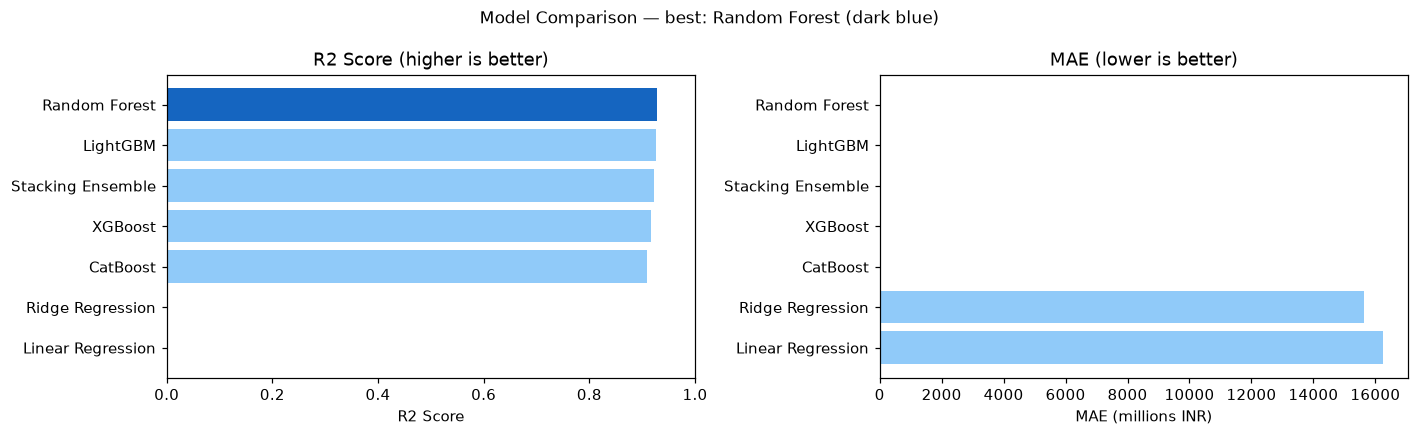

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ["#1565C0" if m == best_model_name else "#90CAF9" for m in results_df["Model"]]

axes[0].barh(results_df["Model"][::-1], results_df["R2 Score"][::-1], color=colors[::-1])
axes[0].set_title("R2 Score (higher is better)")
axes[0].set_xlabel("R2 Score")
axes[0].set_xlim(0, 1)

mae_millions = results_df["MAE (INR)"] / 1e6
axes[1].barh(results_df["Model"][::-1], mae_millions[::-1], color=colors[::-1])
axes[1].set_title("MAE (lower is better)")
axes[1].set_xlabel("MAE (millions INR)")

plt.suptitle(f"Model Comparison — best: {best_model_name} (dark blue)", fontsize=11)
plt.tight_layout()
plt.show()

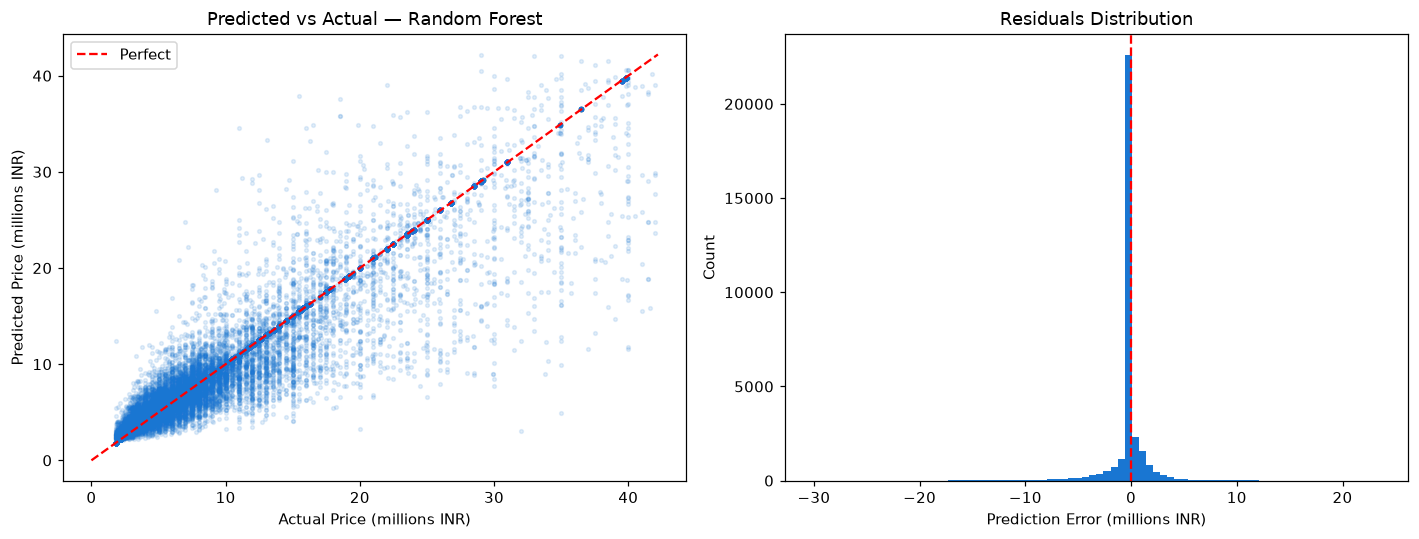

In [31]:
pred_best   = np.expm1(best_pipeline.predict(X_test))
actual_best = np.expm1(y_test)

clip = actual_best.quantile(0.98)
mask = (actual_best <= clip) & (pred_best <= clip)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicted vs actual scatter
axes[0].scatter(actual_best[mask]/1e6, pred_best[mask]/1e6,
                alpha=0.12, s=6, color="#1976D2")
mx = clip / 1e6
axes[0].plot([0, mx], [0, mx], "r--", linewidth=1.5, label="Perfect")
axes[0].set_xlabel("Actual Price (millions INR)")
axes[0].set_ylabel("Predicted Price (millions INR)")
axes[0].set_title(f"Predicted vs Actual — {best_model_name}")
axes[0].legend()

# Residual distribution
residuals = (pred_best[mask] - actual_best[mask]) / 1e6
axes[1].hist(residuals, bins=80, color="#1976D2", edgecolor="none")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Residuals Distribution")
axes[1].set_xlabel("Prediction Error (millions INR)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [32]:
print(f"5-Fold Cross-Validation: {best_model_name}")

cv_scores = cross_val_score(
    best_pipeline, X, y,
    cv=5, scoring="r2", n_jobs=-1,
)

print(f"Fold R2 scores: {[round(s, 4) for s in cv_scores]}")
print(f"Mean R2 : {cv_scores.mean():.4f}")
print(f"Std  R2 : {cv_scores.std():.4f}")

5-Fold Cross-Validation: Random Forest
Fold R2 scores: [np.float64(0.7882), np.float64(0.7604), np.float64(0.8092), np.float64(0.7164), np.float64(0.3104)]
Mean R2 : 0.6769
Std  R2 : 0.1859


In [33]:
best = results_df.iloc[0]
print("=" * 55)
print(f"  Best Model : {best['Model']}")
print(f"  R2 Score   : {best['R2 Score']:.4f}")
print(f"  MAE        : {best['MAE (INR)']:,.0f} INR")
print(f"  RMSE       : {best['RMSE (INR)']:,.0f} INR")
print("=" * 55)

  Best Model : Random Forest
  R2 Score   : 0.9274
  MAE        : 859,589 INR
  RMSE       : 2,602,272 INR


---
## 10. Model Export

In [34]:
import sklearn, xgboost, lightgbm, catboost

print("Dependency versions — pin all of these in backend/requirements.txt:")
print(f"  scikit-learn : {sklearn.__version__}")
print(f"  xgboost      : {xgboost.__version__}")
print(f"  lightgbm     : {lightgbm.__version__}")
print(f"  catboost     : {catboost.__version__}")

Dependency versions — pin all of these in backend/requirements.txt:
  scikit-learn : 1.9.0
  xgboost      : 3.2.0
  lightgbm     : 4.7.0
  catboost     : 1.2.10


In [35]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(best_pipeline, "../models/house_price.pkl")
print("Model saved to models/house_price.pkl")

Model saved to models/house_price.pkl


In [36]:
loaded       = joblib.load("../models/house_price.pkl")
sample       = X_test.iloc[[0]]
pred_inr     = np.expm1(loaded.predict(sample))[0]
actual_inr   = np.expm1(y_test.iloc[0])

print(f"Reload OK")
print(f"Sample prediction : INR {pred_inr:,.0f}")
print(f"Actual value      : INR {actual_inr:,.0f}")
print(f"Error             : {abs(pred_inr - actual_inr)/1e5:.1f} Lac")

Reload OK
Sample prediction : INR 2,200,047
Actual value      : INR 2,200,000
Error             : 0.0 Lac


In [37]:
locations_list = sorted(dc["location_grouped"].dropna().unique().tolist())
json.dump(locations_list, open("../models/locations.json", "w"))
print(f"Saved {len(locations_list)} locations to models/locations.json")
print("Sample:", locations_list[:8])

Saved 51 locations to models/locations.json
Sample: ['agra', 'ahmedabad', 'aurangabad', 'badlapur', 'bangalore', 'bhiwadi', 'bhubaneswar', 'chandigarh']


In [38]:
meta = {
    "best_model": best_model_name,
    "test_r2": round(float(best_r2), 4),
    "test_mae_inr": int(results_df.iloc[0]["MAE (INR)"]),
    "test_rmse_inr": int(results_df.iloc[0]["RMSE (INR)"]),
    "numerical_features": NUMERICAL_FEATURES,
    "cat_ohe_features": CAT_OHE_FEATURES,
    "cat_te_features": CAT_TE_FEATURES,
    "all_features": ALL_FEATURES,
    "target_transform": "log1p",
    "prediction_inverse": "expm1",
}
json.dump(meta, open("../models/feature_meta.json", "w"), indent=2)
print("Saved models/feature_meta.json")
print(json.dumps(meta, indent=2))

Saved models/feature_meta.json
{
  "best_model": "Random Forest",
  "test_r2": 0.9274,
  "test_mae_inr": 859589,
  "test_rmse_inr": 2602272,
  "numerical_features": [
    "area_sqft",
    "log_area",
    "bhk",
    "bathroom",
    "balcony",
    "floor_num",
    "total_floors",
    "floor_ratio",
    "is_top_floor",
    "bath_per_bhk",
    "area_per_bhk",
    "bhk_x_bath"
  ],
  "cat_ohe_features": [
    "Furnishing",
    "Transaction",
    "facing"
  ],
  "cat_te_features": [
    "location_grouped",
    "Ownership"
  ],
  "all_features": [
    "area_sqft",
    "log_area",
    "bhk",
    "bathroom",
    "balcony",
    "floor_num",
    "total_floors",
    "floor_ratio",
    "is_top_floor",
    "bath_per_bhk",
    "area_per_bhk",
    "bhk_x_bath",
    "Furnishing",
    "Transaction",
    "facing",
    "location_grouped",
    "Ownership"
  ],
  "target_transform": "log1p",
  "prediction_inverse": "expm1"
}
